In [3]:
import pandas as pd

df = pd.read_csv("../data/data.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
display(df.head())


Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
for col in df.columns:
    print(col, "->", df[col].dtype)

customerID -> str
gender -> str
SeniorCitizen -> int64
Partner -> str
Dependents -> str
tenure -> int64
PhoneService -> str
MultipleLines -> str
InternetService -> str
OnlineSecurity -> str
OnlineBackup -> str
DeviceProtection -> str
TechSupport -> str
StreamingTV -> str
StreamingMovies -> str
Contract -> str
PaperlessBilling -> str
PaymentMethod -> str
MonthlyCharges -> float64
TotalCharges -> str
Churn -> str


In [7]:
(df["TotalCharges"] == " ").sum()

np.int64(11)

In [8]:
df[df["TotalCharges"] == " "].head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No


In [9]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(df["TotalCharges"].dtype)
print(df["TotalCharges"].isnull().sum())

float64
11


In [10]:
df = df.dropna(subset=["TotalCharges"])
print(df.shape)
print(df["TotalCharges"].isnull().sum())

(7032, 21)
0


In [11]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


/var/folders/v8/qn273y2x533689l7l1q66rfm0000gn/T/ipykernel_60643/2826324352.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="Set2")


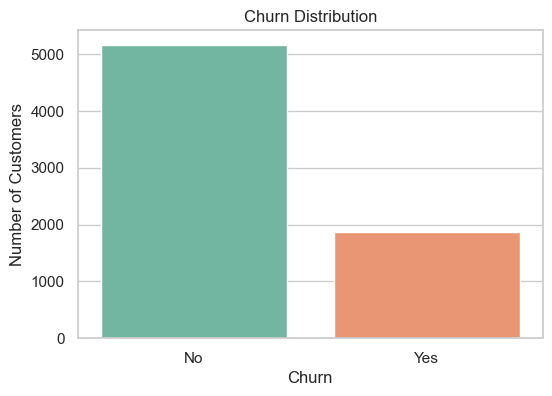

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style=("whitegrid"))

plt.figure(figsize=(6, 4))
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

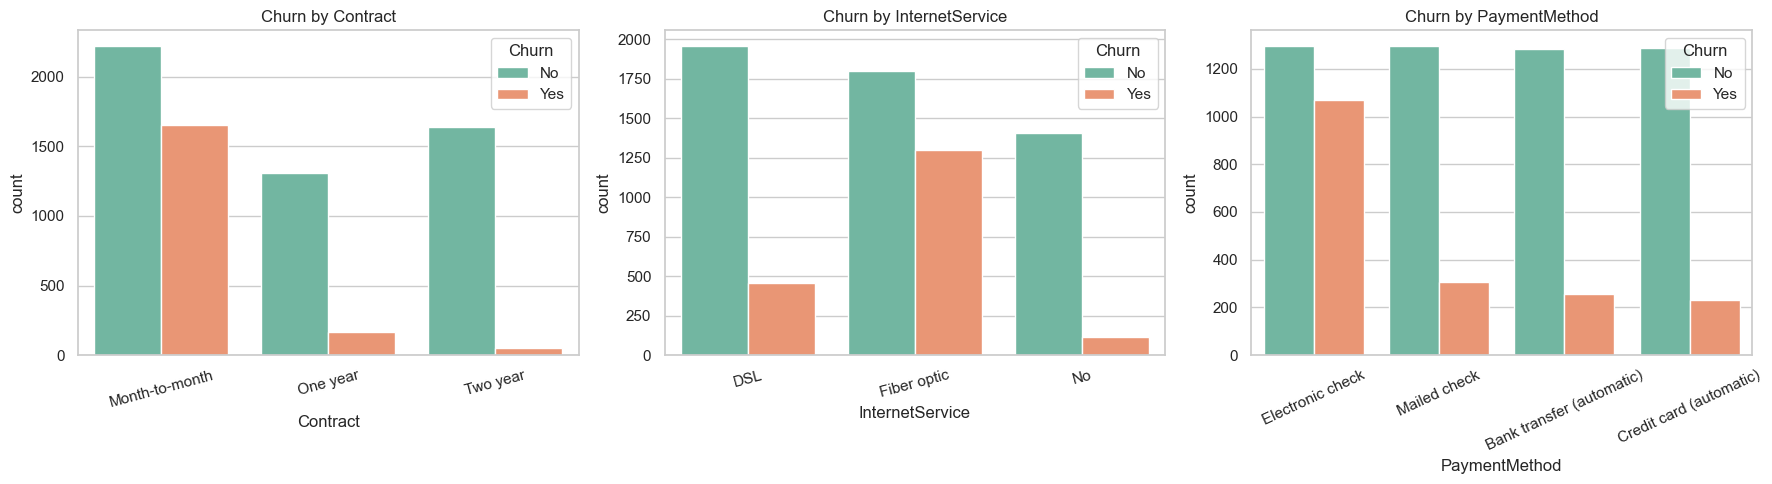

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[0], palette="Set2")
axes[0].set_title("Churn by Contract")
axes[0].tick_params(axis="x", rotation=15)

sns.countplot(data=df, x="InternetService", hue="Churn", ax=axes[1], palette="Set2")
axes[1].set_title("Churn by InternetService")
axes[1].tick_params(axis="x", rotation=15)

sns.countplot(data=df, x="PaymentMethod", hue="Churn", ax=axes[2], palette="Set2")
axes[2].set_title("Churn by PaymentMethod")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

/var/folders/v8/qn273y2x533689l7l1q66rfm0000gn/T/ipykernel_60643/1747446490.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0], palette="Set2")
/var/folders/v8/qn273y2x533689l7l1q66rfm0000gn/T/ipykernel_60643/1747446490.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1], palette="Set2")


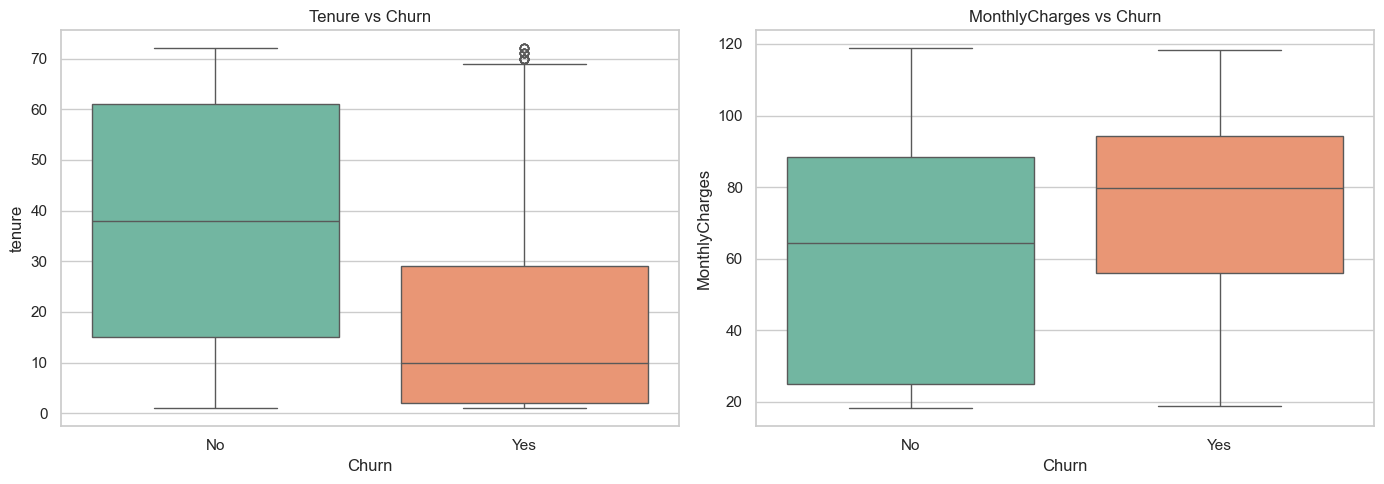

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0], palette="Set2")
axes[0].set_title("Tenure vs Churn")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1], palette="Set2")
axes[1].set_title("MonthlyCharges vs Churn")

plt.tight_layout()
plt.show()

In [15]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.650010,61.307408,2555.344141
Yes,17.979133,74.441332,1531.796094


/var/folders/v8/qn273y2x533689l7l1q66rfm0000gn/T/ipykernel_60643/1747446490.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0], palette="Set2")
/var/folders/v8/qn273y2x533689l7l1q66rfm0000gn/T/ipykernel_60643/1747446490.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1], palette="Set2")


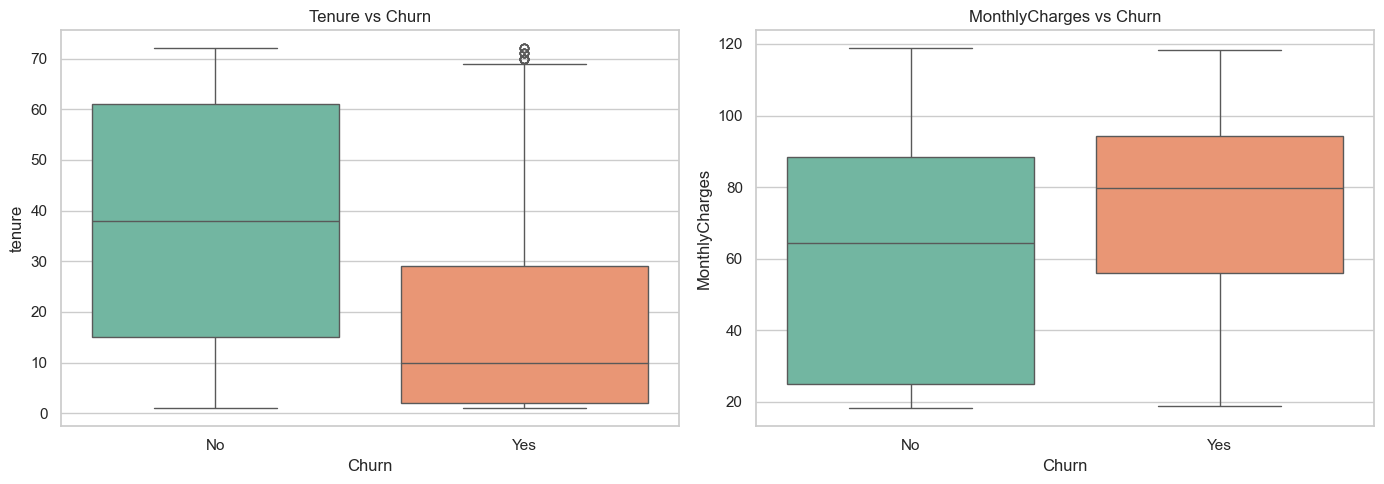

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[0], palette="Set2")
axes[0].set_title("Tenure vs Churn")

sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1], palette="Set2")
axes[1].set_title("MonthlyCharges vs Churn")

plt.tight_layout()
plt.show()

In [18]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.650010,61.307408,2555.344141
Yes,17.979133,74.441332,1531.796094


In [19]:
df_model = df.copy()
df_model = df_model.drop(columns=["customerID"])

X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget values:")
print(y.value_counts())

X shape: (7032, 19)
y shape: (7032,)

Target values:
Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [20]:
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)


Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 19)
X_test: (1407, 19)
y_train: (5625,)
y_test: (1407,)


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

log_reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

log_reg_pipeline.fit(X_train, y_train)

y_pred_log = log_reg_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Accuracy: 0.8038379530916845

Classification Report:
              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Confusion Matrix:
[[917 116]
 [160 214]]


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=100, random_state=42))
    ]
)

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


Accuracy: 0.783226723525231

Classification Report:
              precision    recall  f1-score   support

          No       0.83      0.89      0.86      1033
         Yes       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407


Confusion Matrix:
[[923 110]
 [195 179]]


In [25]:
log_reg_balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
    ]
)

log_reg_balanced_pipeline.fit(X_train, y_train)

y_pred_log_balanced = log_reg_balanced_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log_balanced))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log_balanced))


Accuracy: 0.7256574271499645

Classification Report:
              precision    recall  f1-score   support

          No       0.90      0.70      0.79      1033
         Yes       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407


Confusion Matrix:
[[723 310]
 [ 76 298]]


In [26]:
feature_names = log_reg_balanced_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = log_reg_balanced_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df = coef_df.sort_values(by="coefficient", ascending=False)

print("Top features increasing churn:")
display(coef_df.head(10))

print("\nTop features decreasing churn:")
display(coef_df.tail(10))


Top features increasing churn:


,feature,coefficient
36,cat__Contract_Month-to-month,0.696066
16,cat__InternetService_Fiber optic,0.660906
3,num__TotalCharges,0.607433
32,cat__StreamingTV_Yes,0.252081
35,cat__StreamingMovies_Yes,0.244732
43,cat__PaymentMethod_Electronic check,0.229096
18,cat__OnlineSecurity_No,0.199371
27,cat__TechSupport_No,0.176853
14,cat__MultipleLines_Yes,0.122750
26,cat__DeviceProtection_Yes,0.083315



Top features decreasing churn:


,feature,coefficient
28,cat__TechSupport_No internet service,-0.256902
17,cat__InternetService_No,-0.256902
19,cat__OnlineSecurity_No internet service,-0.256902
34,cat__StreamingMovies_No internet service,-0.256902
31,cat__StreamingTV_No internet service,-0.256902
22,cat__OnlineBackup_No internet service,-0.256902
15,cat__InternetService_DSL,-0.588834
2,num__MonthlyCharges,-0.621137
38,cat__Contract_Two year,-0.777701
1,num__tenure,-1.250374


In [27]:
import pickle

with open("../models/model.pkl", "wb") as f:
    pickle.dump(log_reg_balanced_pipeline, f)

print("Model saved successfully.")


Model saved successfully.


In [28]:
import os
print(os.path.exists("../models/model.pkl"))


True
